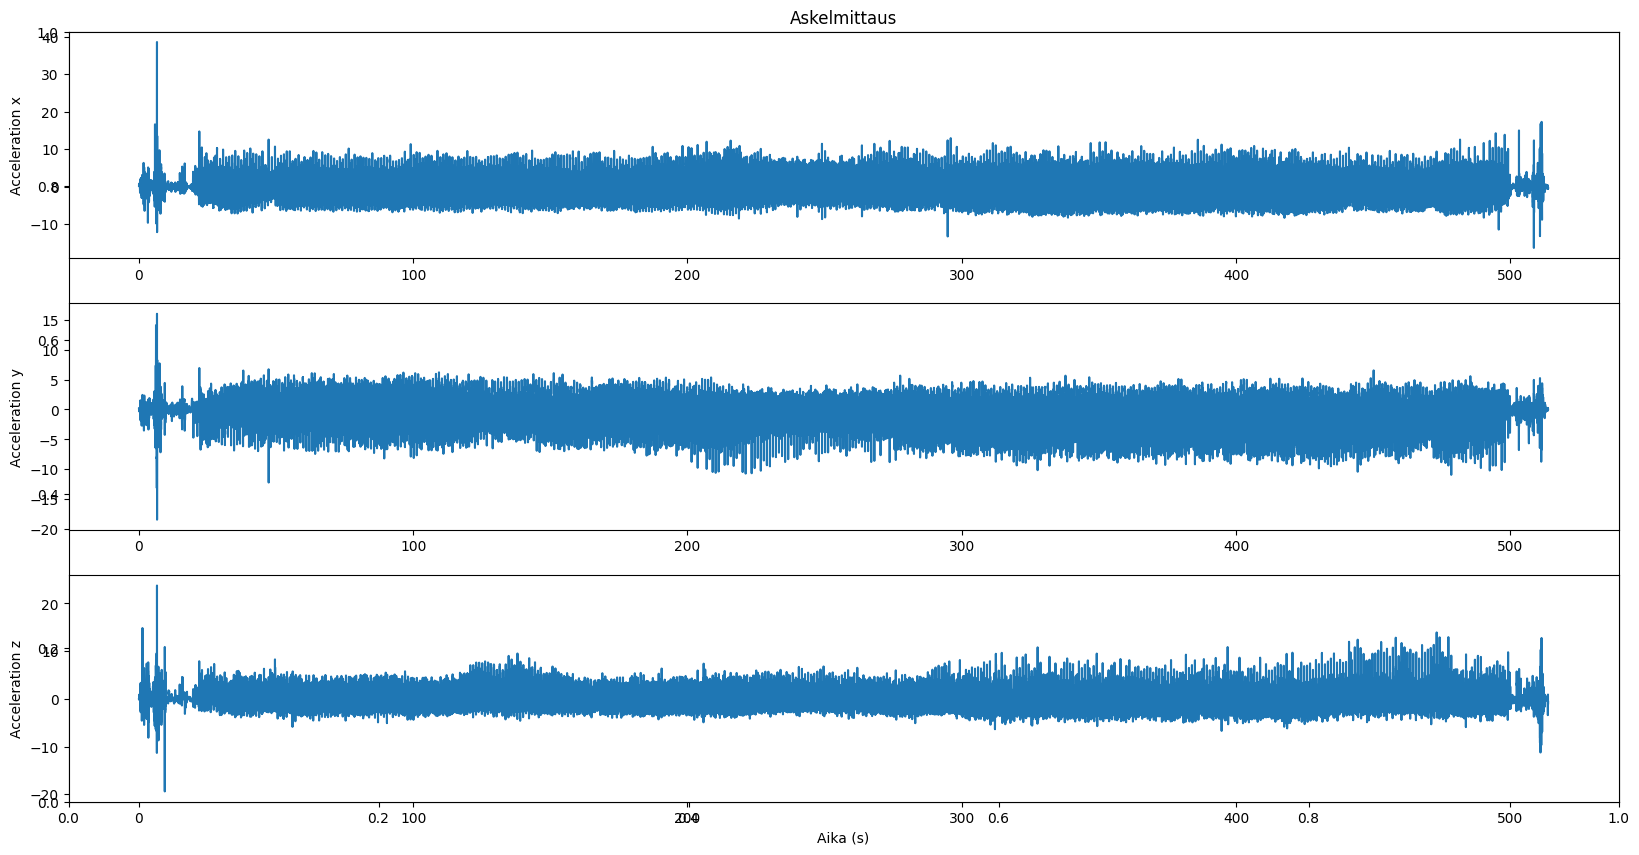

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('./My Experiment/Linear Acceleration.csv')

plt.figure(figsize=(20, 10))

plt.title('Askelmittaus')
plt.subplot(3, 1, 1)
plt.plot(df['Time (s)'], df['Linear Acceleration x (m/s^2)'])
plt.ylabel('Acceleration x')

plt.subplot(3, 1, 2)
plt.plot(df['Time (s)'], df['Linear Acceleration y (m/s^2)'])
plt.ylabel('Acceleration y')

plt.subplot(3, 1, 3)
plt.plot(df['Time (s)'], df['Linear Acceleration z (m/s^2)'])
plt.ylabel('Acceleration z')


plt.xlabel('Aika (s)')

plt.show()


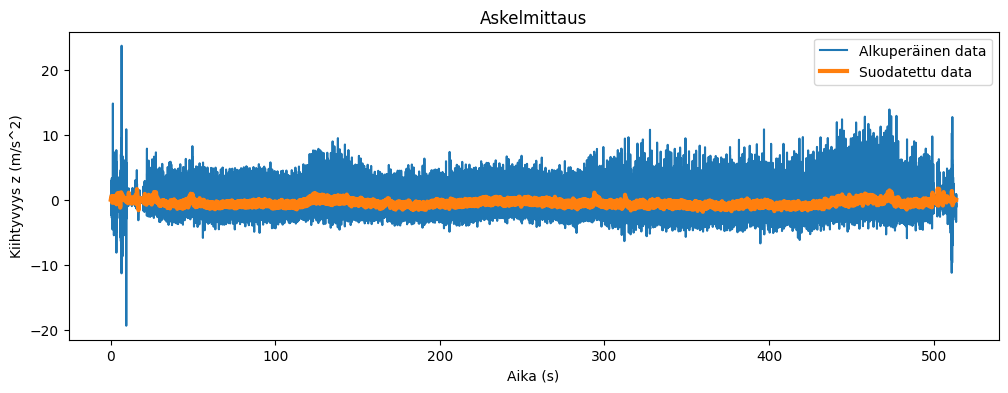

Askelmäärä laskettuna suodatuksen perusteella: 330


In [12]:
# Käytetään alanyysissä z-komponenttia df['Linear Acceleration z (m/s^2)']
# Askelmittarin tulisi pystyä laskemaan jaksojen määrä z-komponentista
# Havaintodatassa on kuitenkin pientä kohinaa (vaihtelua/epätasaisuutta), joten siitä suoraan
# on vaikeaa laskea jaksojen määrää

#Tuodaan filtterifunktiot
from scipy.signal import butter,filtfilt

def butter_lowpass_filter(data, cutoff, fs, nyq, order):
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cutoff, fs, nyq, order):
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

# Data suodatetaan alipäästösuodattimella joka poistaa siitä valittua cutoff-taajuutta suuremmilla taajuuksilla tapahtuvat vaihtelut
# Käytännössä dataa "tasoitetaan" eli alipäästösuodatin vastaa jossain määrin liikkuvan keskiarvon ottamista

data = df['Linear Acceleration z (m/s^2)']
T_tot = df['Time (s)'].max() # Koko datan pituus
n = len(df['Time (s)']) # Datapisteiden lukumäärä
fs = n / T_tot  # Näytteenottotaajuus (oletetaan vakioksi)
nyq = fs/2 # Nyqvistin taajuus, suurin taajuus joka datasta voidaan havaita
order = 3
cutoff = 1/0.7

filtered_data = butter_lowpass_filter(data, cutoff, fs, nyq, order)
plt.figure(figsize=(12, 4))
plt.plot(df['Time (s)'], data, label='Alkuperäinen data')
plt.plot(df['Time (s)'], filtered_data, label='Suodatettu data', linewidth=3)
plt.title('Askelmittaus')
plt.xlabel('Aika (s)')
plt.ylabel('Kiihtyvyys z (m/s^2)')
plt.legend()
#plt.axis([0,30,-3,3])
plt.show()

# Lasketaan askeleet
# Tutkitaan, kuinka usein suodatettu signaali ylittää nollatason

askeleet = 0
for i in range(1, len(filtered_data)):
    if filtered_data[i-1] < 0 and filtered_data[i] >= 0:
        askeleet += 1

print(f'Askelmäärä laskettuna suodatuksen perusteella:', askeleet)


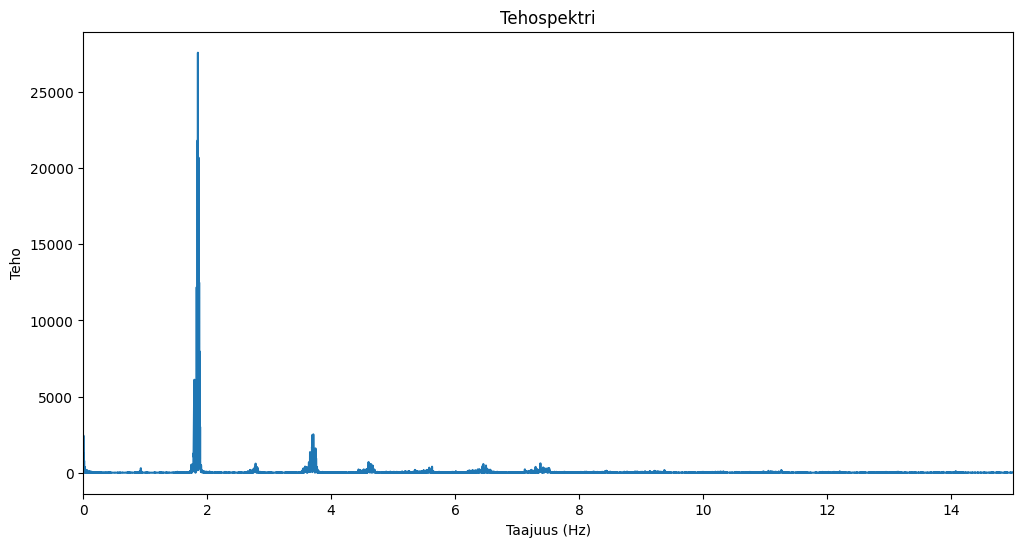

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.read_csv('./My Experiment/Linear Acceleration.csv')

t = data['Time (s)'].values
x = data['Linear Acceleration z (m/s^2)'].values

dt = t[1] - t[0] # Ensimmäisen ja toisen ajan erotus, oletetaan että vakio
N = len(x) # Signaalin pituus

# Fourier-muunnos ja tehospektri
X = np.fft.fft(x, N)
psd = X * np.conj(X) / N
freq = np.fft.fftfreq(N, dt)

# Valitaan vain positiiviset taajuudet
L = np.arange(1, np.floor(N/2), dtype='int')

# Piirretään tehospektri
plt.figure(figsize=(12, 6))
plt.plot(freq[L], psd[L].real)
plt.xlabel("Taajuus (Hz)")
plt.ylabel("Teho")
plt.title("Tehospektri")
plt.xlim(0, 15) 
plt.show()

In [ ]:
import streamlit as st
import pandas as pd
import folium 
from streamlit_folium import st_folium


url = "./My Experiment/Location.csv"
df = pd.read_csv(url)

st.title('My journey to work')

#Print values
st.write("Keskinopeus on :", df['Speed (m/s)'].mean(),'m/s' )
st.write("Kokonaismatka on :", df['Distance (km)'].max(),'km' )

#draw line plot
st.line_chart(df, x = 'Time (s)', y = 'Distance (km)', y_label = 'Distance',x_label = 'Time')

#Create a map where the center is at start_lat start_long and zoom level is defined
start_lat = df['Latitude (°)'].mean()
start_long = df['Longitude (°)'].mean()
map = folium.Map(location = [start_lat,start_long], zoom_start = 14)

#Draw the map
folium.PolyLine(df[['Latitude (°)','Longitude (°)']], color = 'blue', weight = 3.5, opacity = 1).add_to(map)



#Define map dimensions and show the map
st_map = st_folium(map, width=900, height=650)